# Computational Efficiency Visualization Dashboard

This notebook builds the required plots from `results/comp_efficiency/metrics_summary.csv`.

Included visualizations:
1. Bar chart: FPS comparison across all 3 architectures
2. Bar chart: Model size comparison
3. Scatter plot: Accuracy (mAP@0.5) vs average inference time trade-off
4. Memory usage graph: Peak GPU memory (VRAM) during inference

In [2]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Plot style
sns.set_theme(style="whitegrid", context="talk")

# Base path assumes this notebook is in "useful scripts/"
project_root = Path.cwd().parent

metrics_path = project_root / "results" / "comp_efficiency" / "metrics_summary.csv"
fastrcnn_map_path = project_root / "results" / "fastrcnn_run14" / "metrics_summary.csv"
maskrcnn_map_path = project_root / "results" / "maskrcnn_run6" / "metrics_summary.csv"
yolo_history_path = project_root / "results" / "yolo" / "train2" / "results.csv"

df = pd.read_csv(metrics_path)

# Build architecture-wise mAP@0.5 values for trade-off plot
# YOLO: use final metrics/mAP50(B) from training results
yolo_df = pd.read_csv(yolo_history_path)
yolo_map50 = float(yolo_df["metrics/mAP50(B)"].dropna().iloc[-1])

# Faster/Mask: use Overall row in metrics summaries
fastrcnn_df = pd.read_csv(fastrcnn_map_path)
maskrcnn_df = pd.read_csv(maskrcnn_map_path)

faster_map50 = float(
    fastrcnn_df.loc[fastrcnn_df["Class"].str.lower() == "overall", "mAP@0.5"].iloc[0]
)
mask_map50 = float(
    maskrcnn_df.loc[maskrcnn_df["Class"].str.lower() == "overall", "mAP@0.5"].iloc[0]
)

accuracy_map = {
    "YOLOv11": yolo_map50,
    "Faster R-CNN": faster_map50,
    "Mask R-CNN": mask_map50,
}

df["mAP50"] = df["architecture"].map(accuracy_map)

display(df[["architecture", "fps", "model_size_mb", "avg_inference_ms", "peak_vram_mb", "mAP50"]])

,architecture,fps,model_size_mb,avg_inference_ms,peak_vram_mb,mAP50
0,YOLOv11,222.732067,5.281653,4.489699,71.956543,0.98261
1,Faster R-CNN,28.455358,314.904427,35.142767,542.385742,0.97220
2,Mask R-CNN,28.102849,334.936242,35.583581,549.739746,0.97310
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN


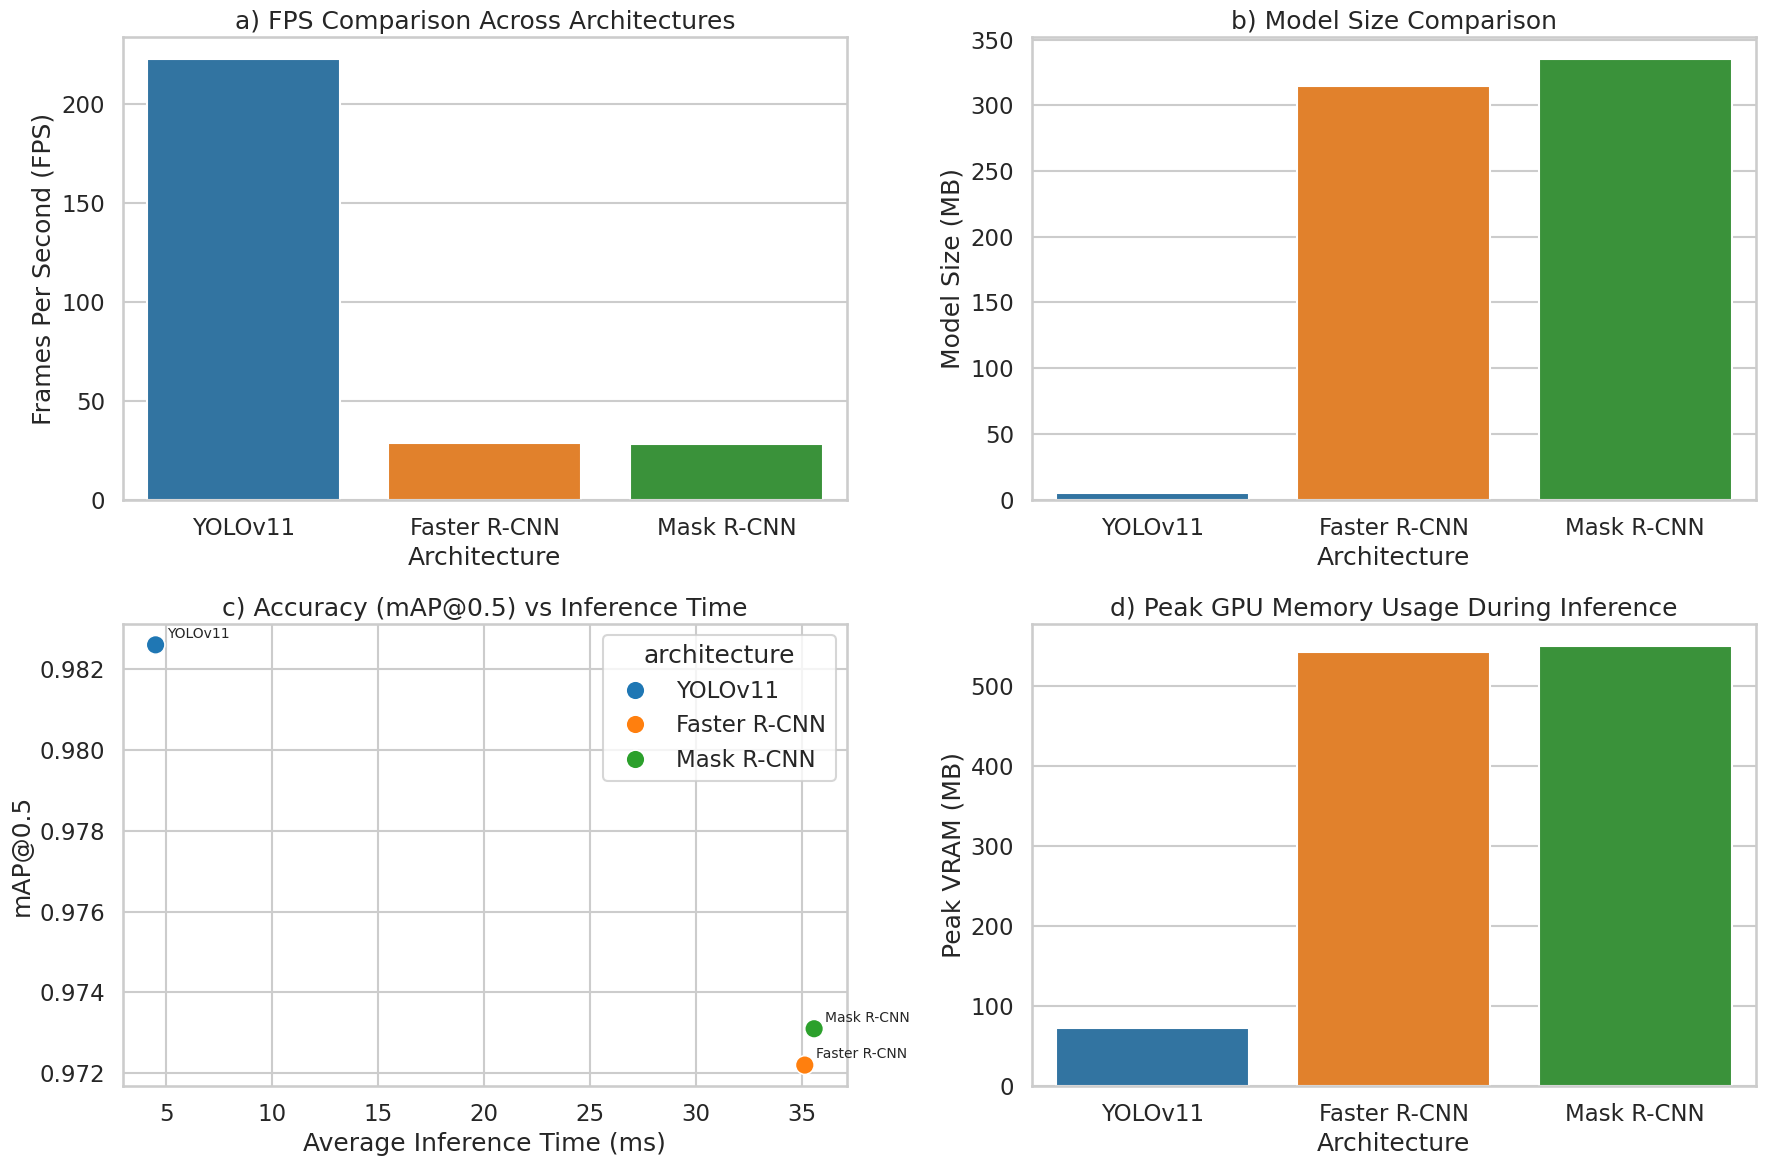

In [3]:
palette = {
    "YOLOv11": "#1f77b4",
    "Faster R-CNN": "#ff7f0e",
    "Mask R-CNN": "#2ca02c",
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1) FPS comparison
sns.barplot(
    data=df,
    x="architecture",
    y="fps",
    hue="architecture",
    palette=palette,
    legend=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("a) FPS Comparison Across Architectures")
axes[0, 0].set_xlabel("Architecture")
axes[0, 0].set_ylabel("Frames Per Second (FPS)")

# 2) Model size comparison
sns.barplot(
    data=df,
    x="architecture",
    y="model_size_mb",
    hue="architecture",
    palette=palette,
    legend=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title("b) Model Size Comparison")
axes[0, 1].set_xlabel("Architecture")
axes[0, 1].set_ylabel("Model Size (MB)")

# 3) Accuracy vs inference-time trade-off
sns.scatterplot(
    data=df,
    x="avg_inference_ms",
    y="mAP50",
    hue="architecture",
    palette=palette,
    s=180,
    ax=axes[1, 0],
)
for _, row in df.iterrows():
    axes[1, 0].annotate(
        row["architecture"],
        (row["avg_inference_ms"], row["mAP50"]),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=10,
    )
axes[1, 0].set_title("c) Accuracy (mAP@0.5) vs Inference Time")
axes[1,  0].set_xlabel("Average Inference Time (ms)")
axes[1, 0].set_ylabel("mAP@0.5")

# 4) GPU memory usage graph
sns.barplot(
    data=df,
    x="architecture",
    y="peak_vram_mb",
    hue="architecture",
    palette=palette,
    legend=False,
    ax=axes[1, 1],
)
axes[1, 1].set_title("d) Peak GPU Memory Usage During Inference")
axes[1, 1].set_xlabel("Architecture")
axes[1, 1].set_ylabel("Peak VRAM (MB)")

plt.tight_layout()
plt.show()

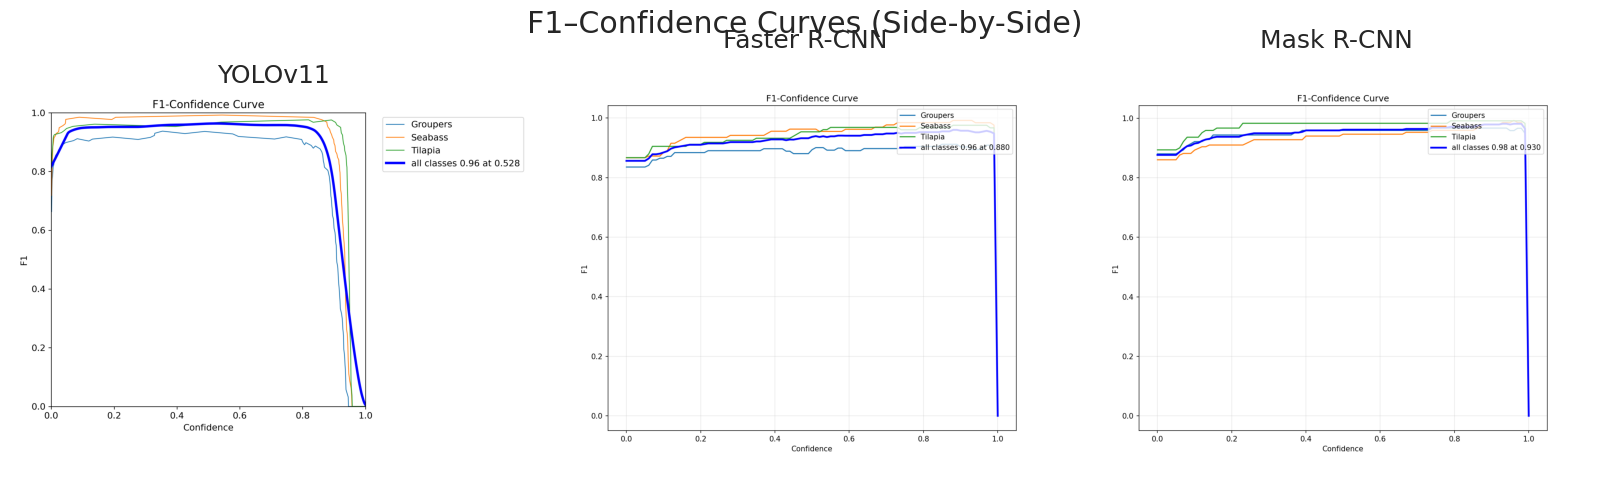

In [7]:
# F1-Confidence curves (side-by-side) for YOLOv11 vs Faster R-CNN vs Mask R-CNN
from pathlib import Path
from matplotlib import image as mpimg
import matplotlib.pyplot as plt

def _pick_existing(*candidates: Path) -> Path:
    for p in candidates:
        if p.exists():
            return p
    cand_str = "\n".join([f"- {p}" for p in candidates])
    raise FileNotFoundError(f"Could not find any of these files:\n{cand_str}")

# Adjust these if you want a different run
yolo_f1_path = _pick_existing(
    project_root / "runs" / "detect" / "train2" / "BoxF1_curve.png",
    project_root / "results" / "yolo" / "train2" / "BoxF1_curve.png",
 )
faster_f1_path = _pick_existing(
    project_root / "results" / "fastrcnn_run14" / "F1_curve.png",
 )
mask_f1_path = _pick_existing(
    project_root / "results" / "maskrcnn_run6" / "F1_curve.png",
 )

paths = {
    "YOLOv11": yolo_f1_path,
    "Faster R-CNN": faster_f1_path,
    "Mask R-CNN": mask_f1_path,
}

# Smaller figure + tighter spacing so the panels sit closer together
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.subplots_adjust(wspace=0.02)  # reduce horizontal whitespace

for ax, (title, img_path) in zip(axes, paths.items()):
    img = mpimg.imread(str(img_path))
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

# Keep a small top margin for the title, but don't push plots apart
plt.suptitle("F1–Confidence Curves (Side-by-Side)", y=0.98)
plt.tight_layout(pad=0.2)
plt.show()

In [9]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from pathlib import Path

weights = Path("/home/somel/code/FYP_Project/models/yolo/yolov11_13_newTilapia.pt")
data_yaml = Path("/home/somel/code/FYP_Project/Dataset/YOLO/version_7/data.yaml")

model = YOLO(str(weights))
m = model.val(data=str(data_yaml), imgsz=640, plots=False)

# The exact attribute names depend on ultralytics version,
# so inspect what's available:
print(type(m))
print([k for k in dir(m) if "curve" in k.lower() or "f1" in k.lower() or "conf" in k.lower()])

Ultralytics 8.3.233 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8151MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 61.3±83.8 MB/s, size: 63.9 KB)
val: Scanning /home/somel/code/FYP_Project/Dataset/YOLO/version_7/valid/labels.cache... 180 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 180/180 453.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 12.6it/s 1.0s0.1s
                   all        180        192      0.972      0.956      0.984      0.908
              Groupers         60         64      0.951      0.915      0.969      0.841
               Seabass         60         65      0.999      0.985      0.995      0.922
               Tilapia         60         63      0.966      0.968      0.988      0.962
Speed: 0.4ms preprocess, 2.2ms inference, 0.0ms loss, 0.8ms postprocess per image
<c